# Spotify Insights — EDA, ETL, clustering e hipóteses

**Disciplina:** Sistemas de Machine Learning — UnB  
**Dataset:** Spotify Tracks Dataset (Kaggle)  
**Escopo desta execução:** proveniência, qualidade, ETL, GQ1 e GQ6 parcial.

Este notebook é o registro acadêmico reproduzível do processo. A lógica de transformação fica em `backend.agentes.etl.pipeline`, que também será usada pelo chatbot; assim, a análise e a aplicação não divergem.

## 1. Objetivos e perguntas

- **GQ1:** Quais atributos de áudio mais diferenciam os gêneros?
- **GQ6 (parcial):** Como a popularidade se distribui no catálogo antes do clustering?

Para GQ1, combinaremos matriz de correlação entre atributos, boxplots dos gêneros mais representativos e `eta²` (proporção de variação explicada pelo gênero). O ranking por `eta²` usa todos os dados; os boxplots usam uma amostra estratificada apenas para legibilidade.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

RAIZ = Path.cwd().resolve()
if not (RAIZ / 'backend').exists():
    RAIZ = RAIZ.parent
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

from backend.agentes.etl.pipeline import (
    ATRIBUTOS_AUDIO,
    carregar_dataset,
    diagnosticar_dados,
    executar_etl,
    localizar_csv_bruto,
)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 100)
DIRETORIO_PLOTS = RAIZ / 'resultados' / 'plots'
DIRETORIO_PLOTS.mkdir(parents=True, exist_ok=True)


## 2. Carregamento e proveniência

O CSV bruto é preservado sem alteração em `dados/brutos/`. O hash SHA-256 abaixo identifica a versão exata analisada.

In [2]:
CAMINHO_CSV = localizar_csv_bruto(RAIZ / 'dados' / 'brutos')
dados_brutos = carregar_dataset(CAMINHO_CSV)
resultado_etl = executar_etl(
    CAMINHO_CSV,
    diretorio_saida=RAIZ / 'dados' / 'tratados',
    diretorio_modelos=RAIZ / 'dados' / 'modelos',
    salvar=True,
)
dados_tratados = resultado_etl.dados_tratados
agregacao_genero = resultado_etl.agregacao_por_genero
relatorio = resultado_etl.relatorio

display(Markdown(
    f"**Arquivo:** `{CAMINHO_CSV.name}`  \n"
    f"**SHA-256:** `{relatorio['proveniencia']['sha256']}`  \n"
    f"**Execução (UTC):** {relatorio['proveniencia']['executado_em_utc']}"
))
dados_brutos.head()


**Arquivo:** `dataset.csv`  
**SHA-256:** `b202fa49909b2d5cef71a04b1d21243cfeb36414535f2ca9272aa646721177bd`  
**Execução (UTC):** 2026-09-01T02:16:25.114482+00:00

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 3. Relatório inicial de qualidade

São apresentados quantidade de linhas e colunas, tipos, valores nulos, duplicatas exatas e repetições de `track_id`. A coluna `Unnamed: 0`, quando existir, é apenas índice exportado pelo CSV e não é uma variável do dataset.

In [3]:
antes = relatorio['antes_do_tratamento']
resumo_inicial = pd.DataFrame({
    'métrica': ['linhas', 'colunas', 'duplicatas exatas', 'duplicatas exatas sem índice', 'track_id repetidos', 'gêneros distintos'],
    'valor': [
        antes['linhas'], antes['colunas'], antes['duplicatas_exatas'],
        antes['duplicatas_exatas_sem_coluna_indice'], antes['track_ids_repetidos'],
        antes['generos_distintos'],
    ],
})
display(resumo_inicial)
display(Markdown('**Nulos por coluna:** ' + (str(antes['nulos_por_coluna']) if antes['nulos_por_coluna'] else 'não há nulos.')))
pd.DataFrame({'tipo': antes['tipos']}).T


,métrica,valor
0,linhas,114000
1,colunas,21
2,duplicatas exatas,0
3,duplicatas exatas sem índice,450
4,track_id repetidos,24259
5,gêneros distintos,114


**Nulos por coluna:** {'artists': 1, 'album_name': 1, 'track_name': 1}

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
tipo,int64,str,str,str,str,int64,int64,bool,float64,float64,int64,float64,int64,float64,float64,float64,float64,float64,float64,int64,str


## 4. Decisões de ETL

1. Remover coluna artificial de índice e duplicatas exatas.
2. Descartar linhas sem `track_id`, `track_name` ou `artists`, pois não podem representar uma faixa recomendável.
3. Preencher `album_name` ausente com `desconhecido`. Para campos numéricos ausentes ou inválidos, usar mediana do gênero padronizado e, na ausência dessa mediana, a mediana global.
4. Padronizar nomes de gênero de forma conservadora: caixa, acentos, hífens e aliases inequívocos; subgêneros são preservados.
5. Consolidar repetidos de `track_id` em uma faixa canônica, reunindo todos os seus gêneros. Metadados numéricos conflitantes são resolvidos pela mediana.
6. Preservar atributos originais e acrescentar versões normalizadas `*_norm` por Min-Max para a etapa de ML.

In [4]:
tratamento = relatorio['tratamento']
depois = relatorio['depois_do_tratamento']
resumo_etl = pd.DataFrame({
    'métrica': [
        'linhas após tratamento', 'colunas após tratamento', 'duplicatas exatas removidas',
        'linhas descartadas (campos obrigatórios)', 'faixas consolidadas por track_id',
        'conflitos numéricos resolvidos pela mediana', 'nulos restantes',
    ],
    'valor': [
        depois['linhas'], depois['colunas'], tratamento['duplicatas_exatas_removidas'],
        tratamento['linhas_descartadas_campos_obrigatorios'], tratamento['faixas_consolidadas_por_track_id'],
        tratamento['conflitos_numericos_resolvidos_por_mediana'], tratamento['nulos_restantes'],
    ],
})
display(resumo_etl)
dados_tratados.head()


,métrica,valor
0,linhas após tratamento,89740
1,colunas após tratamento,30
2,duplicatas exatas removidas,450
3,linhas descartadas (campos obrigatórios),1
4,faixas consolidadas por track_id,23809
5,conflitos numéricos resolvidos pela mediana,720
6,nulos restantes,{}


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,generos,danceability_norm,energy_norm,valence_norm,tempo_norm,acousticness_norm,instrumentalness_norm,speechiness_norm,liveness_norm,loudness_norm
0,0000vdREvCVMxbQTkS888c,Rill,Lolly,Lolly,44.0,160725.0,True,0.910,0.374,8.0,-9.844,0.0,0.1990,0.075700,0.00301,0.1540,0.432,104.042,4.0,german,german,0.923858,0.374,0.434171,0.346396,0.076004,0.00301,0.206218,0.1540,0.734088
1,000CC8EParg64OmTxVnZ0p,Glee Cast,Glee Love Songs,It's All Coming Back To Me Now (Glee Cast Vers...,47.0,322933.0,False,0.269,0.516,0.0,-7.361,1.0,0.0366,0.406000,0.00000,0.1170,0.341,178.174,4.0,club,club,0.273096,0.516,0.342714,0.694153,0.407631,0.00000,0.037927,0.1170,0.780016
2,000Iz0K615UepwSJ5z2RE5,Paul Kalkbrenner;Pig&Dan,X,Böxig Leise - Pig & Dan Remix,22.0,515360.0,False,0.686,0.560,5.0,-13.264,0.0,0.0462,0.001140,0.18100,0.1110,0.108,119.997,4.0,minimal techno,minimal techno,0.696447,0.560,0.108543,0.421242,0.001145,0.18100,0.047876,0.1110,0.670828
3,000RDCYioLteXcutOjeweY,Jordan Sandhu,Teeje Week,Teeje Week,62.0,190203.0,False,0.679,0.770,0.0,-3.537,1.0,0.1900,0.058300,0.00000,0.0825,0.839,161.721,4.0,hip hop,hip hop,0.689340,0.770,0.843216,0.616971,0.058534,0.00000,0.196891,0.0825,0.850748
4,000qpdoc97IMTBvF8gwcpy,Paul Kalkbrenner,Zeit,Tief,19.0,331240.0,False,0.519,0.431,6.0,-13.606,0.0,0.0291,0.000964,0.72000,0.0916,0.234,129.971,4.0,minimal techno,minimal techno,0.526904,0.431,0.235176,0.468031,0.000968,0.72000,0.030155,0.0916,0.664503


## 5. Normalização dos atributos de áudio

`danceability`, `energy`, `valence`, `tempo`, `acousticness`, `instrumentalness`, `speechiness`, `liveness` e `loudness` receberam colunas normalizadas em escala 0–1. O normalizador foi salvo em `dados/modelos/` para que dados futuros da Spotify API sejam projetados na mesma escala.

In [5]:
colunas_norm = [f'{coluna}_norm' for coluna in ATRIBUTOS_AUDIO]
limites_normalizacao = dados_tratados[colunas_norm].agg(['min', 'max']).T
assert limites_normalizacao['min'].ge(0).all() and limites_normalizacao['max'].le(1).all()
limites_normalizacao


,min,max
danceability_norm,0.0,1.0
energy_norm,0.0,1.0
valence_norm,0.0,1.0
tempo_norm,0.0,1.0
acousticness_norm,0.0,1.0
instrumentalness_norm,0.0,1.0
speechiness_norm,0.0,1.0
liveness_norm,0.0,1.0
loudness_norm,0.0,1.0


## 6. GQ1 — atributos de áudio que diferenciam gêneros

A correlação informa quais atributos variam em conjunto, mas não mede diretamente diferença entre grupos. Por isso, o ranking usa `eta²`: quanto maior o valor, maior a parcela da variação daquele atributo associada ao gênero.

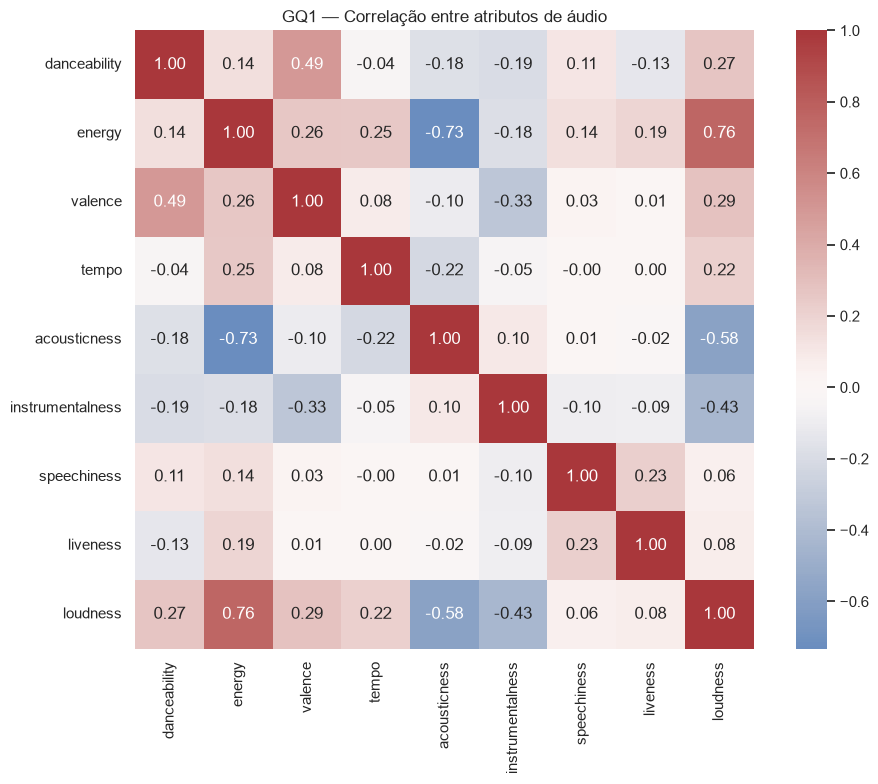

In [6]:
correlacao = dados_tratados[ATRIBUTOS_AUDIO].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlacao, cmap='vlag', center=0, annot=True, fmt='.2f', square=True, ax=ax)
ax.set_title('GQ1 — Correlação entre atributos de áudio')
fig.tight_layout()
fig.savefig(DIRETORIO_PLOTS / 'gq1_correlacao_atributos.png', dpi=180, bbox_inches='tight')
plt.show()


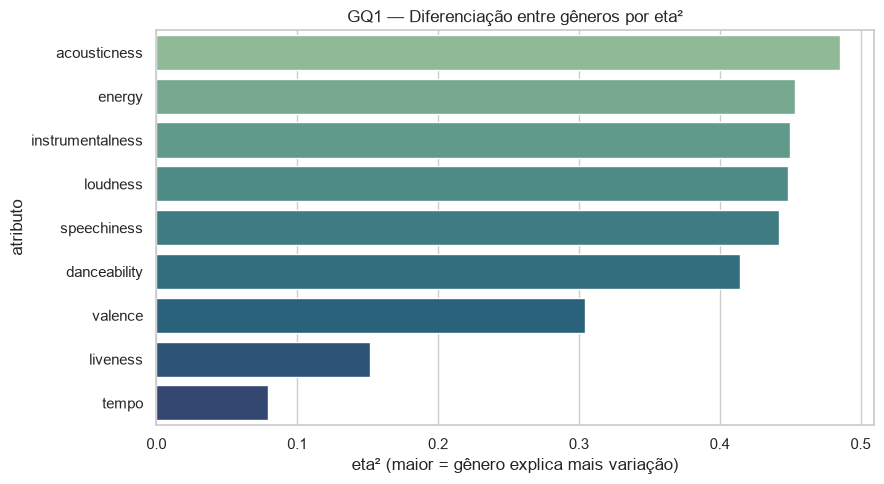

,atributo,eta_quadrado
0,acousticness,0.485
1,energy,0.453
2,instrumentalness,0.450
3,loudness,0.449
4,speechiness,0.442
5,danceability,0.414
6,valence,0.304
7,liveness,0.152
8,tempo,0.079


**Resposta à GQ1:** no catálogo tratado, os três atributos que mais diferenciam os gêneros são **acousticness, energy, instrumentalness**, segundo o ranking por `eta²`.

In [7]:
dados_genero = dados_tratados.assign(
    genero=dados_tratados['generos'].str.split(' | ', regex=False)
).explode('genero')

def eta_quadrado(dados, atributo):
    valores = dados[atributo].dropna()
    if valores.empty or np.isclose(((valores - valores.mean()) ** 2).sum(), 0):
        return 0.0
    media_global = valores.mean()
    resumo = dados.dropna(subset=[atributo]).groupby('genero')[atributo].agg(['count', 'mean'])
    soma_entre = (resumo['count'] * (resumo['mean'] - media_global) ** 2).sum()
    soma_total = ((valores - media_global) ** 2).sum()
    return float(soma_entre / soma_total)

ranking_gq1 = pd.DataFrame({
    'atributo': ATRIBUTOS_AUDIO,
    'eta_quadrado': [eta_quadrado(dados_genero, atributo) for atributo in ATRIBUTOS_AUDIO],
}).sort_values('eta_quadrado', ascending=False, ignore_index=True)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=ranking_gq1, x='eta_quadrado', y='atributo', hue='atributo', legend=False, palette='crest', ax=ax)
ax.set_title('GQ1 — Diferenciação entre gêneros por eta²')
ax.set_xlabel('eta² (maior = gênero explica mais variação)')
ax.set_ylabel('atributo')
fig.tight_layout()
fig.savefig(DIRETORIO_PLOTS / 'gq1_ranking_eta_quadrado.png', dpi=180, bbox_inches='tight')
plt.show()
display(ranking_gq1.style.format({'eta_quadrado': '{:.3f}'}))
destaques = ', '.join(ranking_gq1.head(3)['atributo'])
display(Markdown(f'**Resposta à GQ1:** no catálogo tratado, os três atributos que mais diferenciam os gêneros são **{destaques}**, segundo o ranking por `eta²`.'))


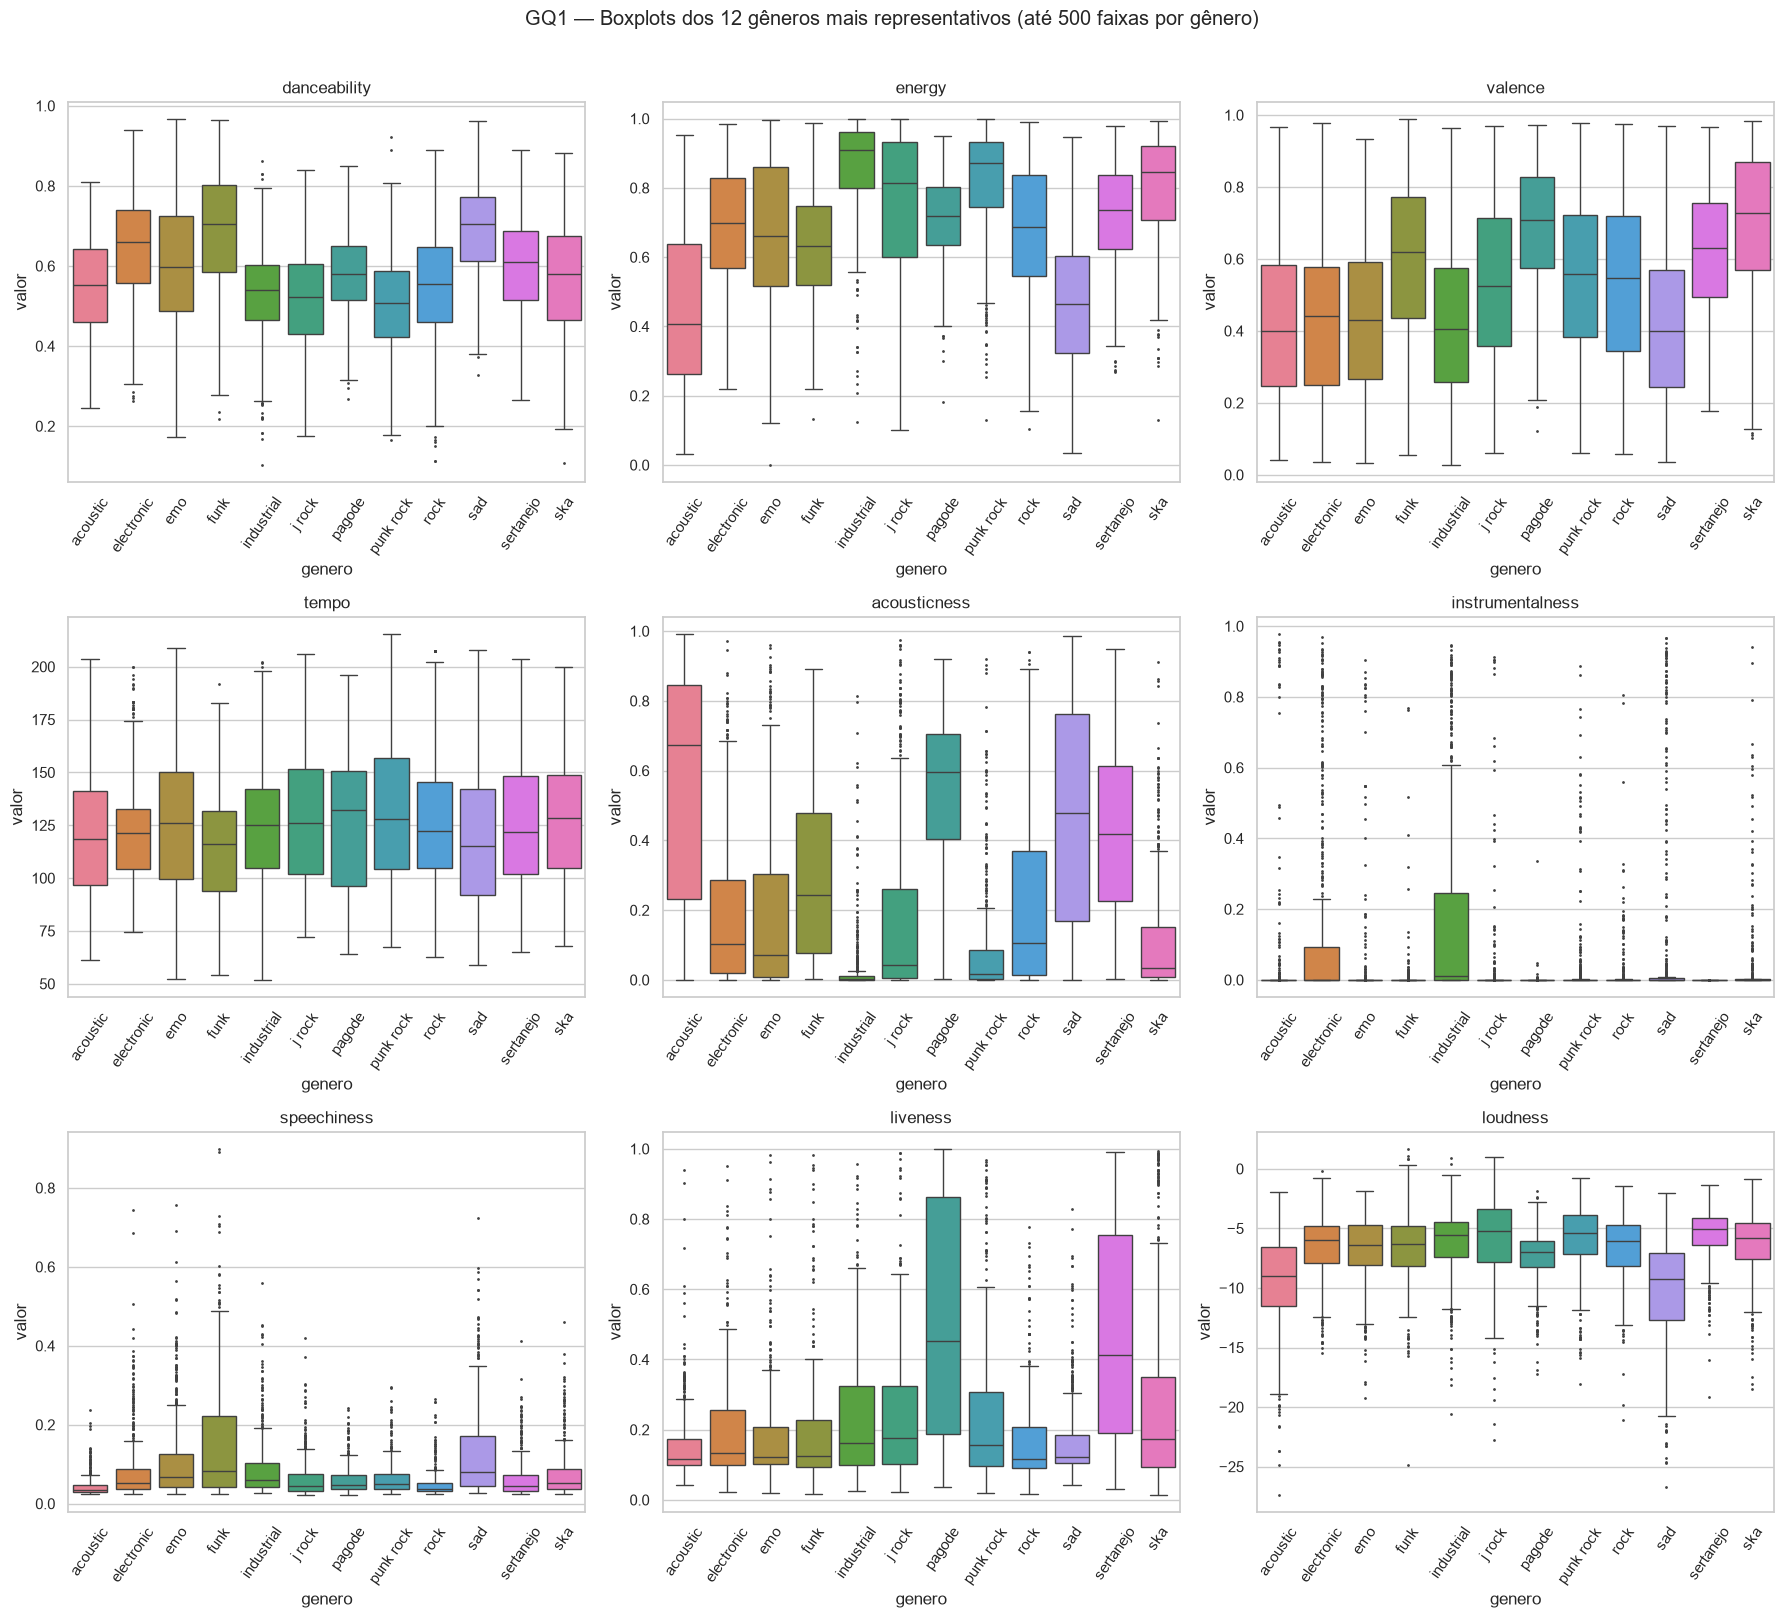

In [8]:
top_generos = dados_genero['genero'].value_counts().head(12).index
amostra_boxplot = (
    dados_genero[dados_genero['genero'].isin(top_generos)]
    .groupby('genero', group_keys=False)
    .sample(n=500, random_state=42)
)
longa = amostra_boxplot.melt(id_vars='genero', value_vars=ATRIBUTOS_AUDIO, var_name='atributo', value_name='valor')
fig, axes = plt.subplots(3, 3, figsize=(18, 16), sharex=False)
for eixo, atributo in zip(axes.flat, ATRIBUTOS_AUDIO):
    sns.boxplot(data=longa[longa['atributo'] == atributo], x='genero', y='valor', hue='genero', legend=False, fliersize=1, ax=eixo)
    eixo.set_title(atributo)
    eixo.tick_params(axis='x', rotation=55)
fig.suptitle('GQ1 — Boxplots dos 12 gêneros mais representativos (até 500 faixas por gênero)', y=1.01)
fig.tight_layout()
fig.savefig(DIRETORIO_PLOTS / 'gq1_boxplots_generos.png', dpi=180, bbox_inches='tight')
plt.show()


## 7. GQ6 (parcial) — distribuição de popularidade

Esta análise descreve a variável `popularity` antes de qualquer cluster. Ela não deve ser interpretada como preferência individual do usuário nem como medida de qualidade musical.

,popularidade
count,89740.000000
mean,33.198267
std,20.577679
min,0.000000
1%,0.000000
5%,0.000000
25%,19.000000
50%,33.000000
75%,49.000000
95%,67.000000


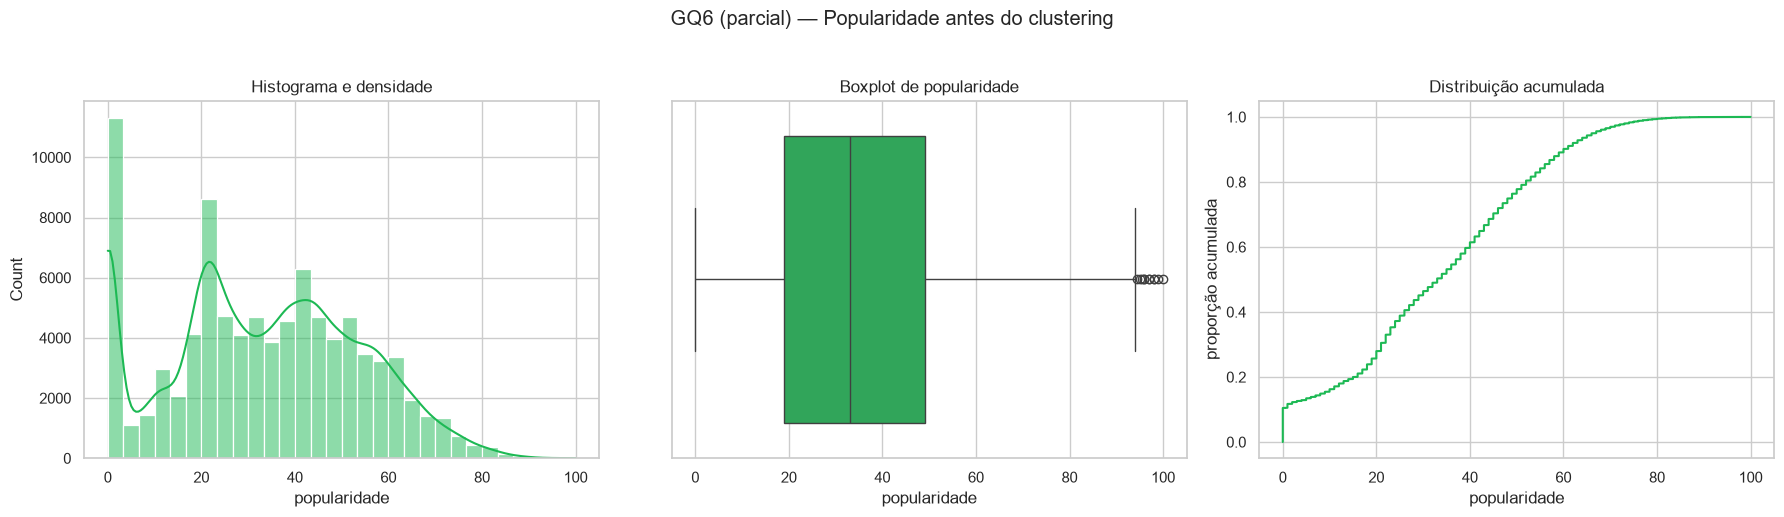

**Resposta parcial à GQ6:** a popularidade possui média de **33.20**, mediana de **33.00** e assimetria de **0.07**. Os gráficos mostram a distribuição observada antes de qualquer agrupamento.

In [9]:
estatisticas_popularidade = dados_tratados['popularity'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).to_frame('popularidade')
display(estatisticas_popularidade)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(dados_tratados['popularity'], bins=30, kde=True, ax=axes[0], color='#1DB954')
axes[0].set_title('Histograma e densidade')
axes[0].set_xlabel('popularidade')

sns.boxplot(x=dados_tratados['popularity'], ax=axes[1], color='#1DB954')
axes[1].set_title('Boxplot de popularidade')
axes[1].set_xlabel('popularidade')

popularidade_ordenada = np.sort(dados_tratados['popularity'].dropna())
axes[2].plot(popularidade_ordenada, np.arange(1, len(popularidade_ordenada) + 1) / len(popularidade_ordenada), color='#1DB954')
axes[2].set_title('Distribuição acumulada')
axes[2].set_xlabel('popularidade')
axes[2].set_ylabel('proporção acumulada')
fig.suptitle('GQ6 (parcial) — Popularidade antes do clustering', y=1.03)
fig.tight_layout()
fig.savefig(DIRETORIO_PLOTS / 'gq6_distribuicao_popularidade.png', dpi=180, bbox_inches='tight')
plt.show()
media = dados_tratados['popularity'].mean()
mediana = dados_tratados['popularity'].median()
assimetria = dados_tratados['popularity'].skew()
display(Markdown(
    f'**Resposta parcial à GQ6:** a popularidade possui média de **{media:.2f}**, mediana de **{mediana:.2f}** e assimetria de **{assimetria:.2f}**. ' 
    'Os gráficos mostram a distribuição observada antes de qualquer agrupamento.'
))


## 8. Agregação por gênero e exportação

A agregação abaixo alimentará respostas de descoberta do chatbot. O catálogo tratado, a agregação, os metadados e o normalizador já foram persistidos pelo mesmo pipeline usado neste notebook.

In [10]:
display(agregacao_genero.head(15))
display(Markdown('**Artefatos gerados:**'))
for nome, caminho in resultado_etl.arquivos.items():
    print(f'- {nome}: {caminho.relative_to(RAIZ)}')

assert (RAIZ / 'dados' / 'tratados' / 'spotify_tracks_tratado.csv').exists()
assert (RAIZ / 'dados' / 'tratados' / 'agregacao_por_genero.csv').exists()
assert (RAIZ / 'dados' / 'modelos' / 'normalizador_atributos.joblib').exists()


,genero,quantidade_faixas,media_popularity,media_danceability,media_energy,media_valence,media_tempo,media_acousticness,media_instrumentalness,media_speechiness,media_liveness,media_loudness,media_danceability_norm,media_energy_norm,media_valence_norm,media_tempo_norm,media_acousticness_norm,media_instrumentalness_norm,media_speechiness_norm,media_liveness_norm,media_loudness_norm
0,electronic,1922,39.98257,0.652032,0.680007,0.430541,122.096473,0.202276,0.141664,0.079512,0.188513,-6.637364,0.661961,0.680007,0.432705,0.431091,0.203088,0.141664,0.082396,0.188513,0.793401
1,acoustic,1000,42.48350,0.549593,0.435368,0.424023,119.010624,0.566816,0.038336,0.043247,0.153244,-9.447843,0.557962,0.435368,0.426154,0.416615,0.569093,0.038336,0.044816,0.153244,0.741416
2,british,1000,43.80000,0.501276,0.507127,0.439714,118.828617,0.427943,0.193679,0.050010,0.174298,-10.519963,0.508909,0.507127,0.441924,0.415761,0.429662,0.193679,0.051824,0.174298,0.721585
3,country,1000,17.02950,0.555294,0.596805,0.521481,123.963307,0.321227,0.005585,0.042268,0.177238,-7.281778,0.563750,0.596805,0.524102,0.439848,0.322517,0.005585,0.043801,0.177238,0.781481
4,disco,1000,33.52150,0.676692,0.737565,0.670754,121.974380,0.166213,0.080952,0.059252,0.195325,-7.422032,0.686997,0.737565,0.674124,0.430518,0.166880,0.080952,0.061401,0.195325,0.778887
5,emo,1000,48.11950,0.599321,0.669967,0.441135,126.992643,0.195081,0.030281,0.108957,0.183738,-6.718621,0.608448,0.669967,0.443352,0.454059,0.195864,0.030281,0.112909,0.183738,0.791898
6,funk,1000,32.32200,0.678184,0.632999,0.599653,117.755823,0.299657,0.007798,0.151649,0.180557,-6.503946,0.688512,0.632999,0.602666,0.410729,0.300860,0.007798,0.157149,0.180557,0.795869
7,garage,1000,40.93250,0.484264,0.744350,0.518033,127.048215,0.167507,0.189870,0.065934,0.212687,-6.553586,0.491639,0.744350,0.520636,0.454320,0.168180,0.189870,0.068325,0.212687,0.794951
8,indie pop,1000,40.65750,0.604370,0.561140,0.460615,120.179009,0.372357,0.041933,0.065861,0.167419,-7.996607,0.613574,0.561140,0.462930,0.422096,0.373852,0.041933,0.068250,0.167419,0.768259
9,industrial,1000,31.04000,0.530416,0.861745,0.424874,126.831205,0.036728,0.192031,0.086817,0.232987,-6.024399,0.538493,0.861745,0.427009,0.453302,0.036875,0.192031,0.089965,0.232987,0.804739


**Artefatos gerados:**

- catalogo_tratado: dados\tratados\spotify_tracks_tratado.csv
- agregacao_generos: dados\tratados\agregacao_por_genero.csv
- metadados: dados\tratados\metadados_etl.json
- normalizador: dados\modelos\normalizador_atributos.joblib


## 9. Hipóteses, clustering e recomendação — próximas etapas

O ETL não escolhe número de clusters nem produz recomendações. Nas próximas células, o grupo deverá registrar hipóteses, comparar configurações de clustering, interpretar os grupos e validar novidade para não recomendar faixas já presentes no histórico do usuário.

In [11]:
# TODO(Fase 2): preparar matriz de features, comparar clustering e registrar hipóteses.


## 10. GQ3 — top tracks de usuários e clusters (TODO: Fase 4)

Esta pergunta só será respondida depois que o modelo de clustering e o scaler forem treinados e avaliados na Fase 4. Para 2–3 usuários de teste (reais autorizados ou personas demo), projetar as top tracks no mesmo espaço de features, calcular o cluster dominante, sua proporção e a entropia da distribuição, e comparar os gráficos por usuário.

**Critério proposto:** considerar perfil concentrado quando ao menos 70% das top tracks caírem no cluster dominante; caso contrário, classificá-lo como espalhado. Não usar dados da Spotify API no modelo antes da revisão de conformidade.

In [ ]:
# TODO(Fase 4): carregar scaler/modelo, projetar 2–3 coletas demo ou autorizadas e responder GQ3.


## 10. Limitações e reprodutibilidade

- O dataset representa o catálogo disponibilizado no Kaggle, não o comportamento de todos os usuários do Spotify.
- Gênero é uma taxonomia editorial e pode existir em mais de uma categoria por faixa.
- A normalização é ajustada sobre este catálogo e o artefato salvo deve ser reutilizado para dados novos.
- Popularidade é uma variável observacional; esta análise não estabelece causalidade.